In [1]:
import geopandas as gpd
import pandas as pd
import os
import numpy as np
import rasterio as rio
import glob
import matplotlib.pyplot as plt
from subprocess import Popen

In [2]:
mainPath = '/projectnb/modislc/users/sjstone/above/'

## generating a classification that is a combination of the three dates to get overall class

In [53]:
glob.glob(mainPath + 'data/classification/*0819*fullExt*')

['/projectnb/modislc/users/sjstone/above/data/classification/20230714RNIR_20230819RNIR_PCA_classification_V2_fullExt.tif']

In [58]:
# reading in the classification with the matching extents

fullExt0819 = rio.open(glob.glob(mainPath + 'data/classification/*0819*V2*fullExt*')[0])
fullExt0819Read = fullExt0819.read()
fullExt0920 = rio.open(glob.glob(mainPath + 'data/classification/*0920*V5*fullExt*')[0])
fullExt0920Read = fullExt0920.read()
fullExt0806 = rio.open(glob.glob(mainPath + 'data/classification/*0806*V3*')[0])
fullExt0806Read = fullExt0806.read().astype(fullExt0819Read.dtype.name)

In [59]:
# assigning areas that are outside of the classification area values of 0

fullExt0819Read[:, fullExt0819Read[0,:,:] <= 0] = 0
fullExt0920Read[:, fullExt0920Read[0,:,:] <= 0] = 0
fullExt0806Read[:, fullExt0806Read[0,:,:] == 0] = 0

In [60]:
# assigning areas that are classified in the August 19th classification values of 0 for the other two classifications 

fullExt0920Read[:, fullExt0819Read[0,:,:] > 0] = 0
fullExt0806Read[:, fullExt0819Read[0,:,:] > 0] = 0

In [61]:
# multiplying the september 20th classification to have the ability to identify the differences 
# between the different classifications for the combined areas
fullExt0920Read = fullExt0920Read * 10

In [62]:
# generating a dictionary with the values that the combined values should be changed to
crosswalk_dict = {
    0:0,
    1:1,
    2:2,
    11:1,
    22:2,
    21:3, # adding a new class with value 3 that will identify areas where the September 20th classification adds additional ALD
    12:2
}

In [63]:
# adding the three classifications together
combine = fullExt0920Read + fullExt0806Read + fullExt0819Read

In [65]:
# crosswalking the combined classification
combineCrosswalk = np.vectorize(crosswalk_dict.get)(combine)

## combining the august 19 and september 20th classification to compare with august 6 to get a change map

In [3]:
fullExt0819 = rio.open(glob.glob(mainPath + 'data/classification/*0819*V2*fullExt*')[0])
fullExt0819Read = fullExt0819.read()
fullExt0920 = rio.open(glob.glob(mainPath + 'data/classification/*0920*V5*fullExt*')[0])
fullExt0920Read = fullExt0920.read()

In [4]:
fullExt0819Read[:, fullExt0819Read[0,:,:] <= 0] = 0
fullExt0920Read[:, fullExt0920Read[0,:,:] <= 0] = 0

In [5]:
fullExt0920Read[:, fullExt0819Read[0,:,:] > 0] = 0
fullExt0920Read[:, fullExt0920Read[0,:,:] == 2] = 3

In [6]:
combined = fullExt0920Read + fullExt0819Read

In [35]:
fullExt0806 = rio.open(glob.glob(mainPath + 'data/classification/*0806RNIR*V3*')[0])
fullExt0806Read = fullExt0806.read().astype(fullExt0819Read.dtype.name)

In [34]:
glob.glob(mainPath + 'data/classification/*0806RNIR*V3*')

['/projectnb/modislc/users/sjstone/above/data/classification/20230714RNIR_20230806RNIR_PCA_classification_V3.tif']

In [9]:
# saving the tif file that has the combined classification to cover the full area
# rio.open(
#         mainPath + 'data/classification/20230704_20230819V2_20230920V5_RNIR_PCA_class_combine_V2.tif',
#         'w',
#         height=combined.shape[1],
#         width=combined.shape[2],
#         count=combined.shape[0],
#         dtype=combined.dtype.name,
#         crs=fullExt0819.crs,
#         transform=fullExt0819.transform,
#         compress='lzw'
#     ).write(combined)

In [37]:
# converting the raster to vector
command = [
    'gdal_polygonize.py',
    mainPath + 'data/classification/20230714RNIR_20230806RNIR_PCA_classification_V3.tif',
    '-b',
    '1',
    '-f',
    'ESRI Shapefile',
    mainPath + 'data/classification_vector/V2/20230714RNIR_20230806RNIR_PCA_classification_V3.shp',
    '20230714RNIR_20230806RNIR_PCA_classification_V3',
    'Class'
]
Popen(command).wait()

0...10...20...30...40...50...60...70...80...90...Creating output /projectnb/modislc/users/sjstone/above/data/classification_vector/V2/20230714RNIR_20230806RNIR_PCA_classification_V3.shp of format ESRI Shapefile.
100 - done.


0

In [38]:
sizeLim = 45

In [39]:
vectorized = gpd.read_file(mainPath + 'data/classification_vector/V2/20230714RNIR_20230806RNIR_PCA_classification_V3.shp')

In [40]:
vectorized['area'] = vectorized.area

In [41]:
vectorized['area'] = vectorized.area.abs()

In [42]:
smallPolyLoc = vectorized[vectorized['area'] <= sizeLim].index

In [43]:
smallPolydf = vectorized[vectorized['area'] <= sizeLim]

In [44]:
smallPolydf['neighbors'] = np.nan
smallPolydf['neighborsArea'] = np.nan

smallPolydf['neighbors'] = smallPolydf['neighbors'].astype('object')
smallPolydf['neighborsArea'] = smallPolydf['neighbors'].astype('object')

/projectnb/modislc/users/sjstone/GeoEnv2/lib/python3.8/site-packages/geopandas/geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/projectnb/modislc/users/sjstone/GeoEnv2/lib/python3.8/site-packages/geopandas/geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [45]:
for index, row in smallPolydf.iterrows():
    neighborsDF = vectorized[vectorized.geometry.touches(row['geometry'])]
    neighborsClass = list(neighborsDF.Class)
    neighborsArea = list(neighborsDF.area)
#     neighbors = neighbors.remove(row.name)
#     smallPolydf.at[index, "neighbors"] = ", ".join(str(e) for e in neighbors)
    smallPolydf.at[index, 'neighbors'] = list(neighborsDF.Class)
    smallPolydf.at[index, 'neighborsArea'] = list(neighborsDF.area)
#     smallPolydf.at[index, 'neighborsArea'] = neighborsArea

# neighbors = np.array(vectorized[vectorized.geometry.touches(row['geometry'])].name)

In [46]:
vectorized['neighbors'] = smallPolydf.neighbors
vectorized['neighborsArea'] = smallPolydf.neighborsArea

In [47]:
updatedDict = {
    2: 1,
    1: 2,
    3: 1
}

In [48]:
def changeClass(row):
    current = row.Class
    neighborList = row.neighbors
    neighborArea = row.neighborsArea
    
    if current in neighborList:
        sameLCArea = np.array(neighborArea)[np.array(neighborList) == current]
        numSmall = len(list(sameLCArea[sameLCArea <= sizeLim]))
        if numSmall > 0:
            changeClass = updatedDict[current]
        else:
            changeClass = current
    elif current == 2:
        if current + 1 in neighborList:
            changeClass = current
        else:
            changeClass = 1
    elif current == 3:
        if current - 1 in neighborList:
            changeClass = current
        else: 
            changeClass = 1
    else:
        if len(neighborList) == 1:
            changeClass = neighborList[0]
        else:
            changeClass = 2
    
    return(changeClass)

In [49]:
vectorized['updatedClass'] = vectorized['Class']

In [24]:
# smallPolyLoc = vectorized[vectorized['area'] <= 40].index

In [50]:
vectorized.loc[vectorized['area'] <= sizeLim, 'updatedClass'] = vectorized.loc[vectorized['area'] <= sizeLim, :].apply(lambda x: changeClass(x), axis = 1)

In [51]:
vectorized

,Class,geometry,area,neighbors,neighborsArea,updatedClass
0,2,"POLYGON ((574293.000 7726386.000, 574296.000 7...",27.0,[1],[161469063.0],1
1,2,"POLYGON ((574290.000 7726377.000, 574296.000 7...",90.0,NaN,NaN,2
2,2,"POLYGON ((574065.000 7726350.000, 574068.000 7...",9.0,[1],[161469063.0],1
3,2,"POLYGON ((574053.000 7726362.000, 574056.000 7...",351.0,NaN,NaN,2
4,2,"POLYGON ((574062.000 7726320.000, 574068.000 7...",27.0,[1],[161469063.0],1
...,...,...,...,...,...,...
716,2,"POLYGON ((575907.000 7716723.000, 575913.000 7...",189.0,NaN,NaN,2
717,0,"POLYGON ((564816.000 7727676.000, 573039.000 7...",37368207.0,NaN,NaN,0
718,1,"POLYGON ((573039.000 7727676.000, 573051.000 7...",161469063.0,NaN,NaN,1
719,0,"POLYGON ((567573.000 7718676.000, 567579.000 7...",30488787.0,NaN,NaN,0


In [53]:
vectorized = vectorized.drop(columns = ['neighbors', 'neighborsArea'])

In [46]:
# vectorizedDissolve = vectorized.dissolve('updatedClass')
# dissolveBuf = vectorizedDissolve.buffer(0.1)
# vectorizedDissolve['geometry'] = vectorized.buffer(0.1)
# vectorizedDissolve = vectorizedDissolve.set_geometry('geometry')

In [47]:
# vectorizedExplode = dissolveBuf.explode(index_parts = False)
# vectorizedExplode = vectorizedExplode.reset_index()
# vectorizedExplode['geometry'] = vectorizedExplode.buffer(-0.1)
# vectorizedExplode = vectorizedExplode.drop(columns = 0)
# vectorizedExplode = vectorizedExplode.set_geometry('geometry')

In [49]:
# vectorizedExplode['area'] = vectorizedExplode.area

In [54]:
vectorized.to_file(mainPath + 'data/classification_vector/V2/20230714RNIR_20230806RNIR_PCA_classification_V3_' + str(sizeLim) +'min_V1.shp')

/scratch/238673.1.ood/ipykernel_943742/961744738.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  vectorized.to_file(mainPath + 'data/classification_vector/V2/20230714RNIR_20230806RNIR_PCA_classification_V3_' + str(sizeLim) +'min_V1.shp')


In [ ]:
gdal_rasterize -l 20230704_20230806_20230819_20230920_RNIR_PCA_class_combine_V1_45min_V2 -a updatedCla -tr 3.0 3.0 -a_nodata 0.0 -te 564816.0 7711941.0 584802.0 7727676.0 -ot Float32 -of GTiff /projectnb/modislc/users/sjstone/above/data/classification_vector/20230704_20230806_20230819_20230920_RNIR_PCA_class_combine_V1_45min_V2.shp /projectnb/modislc/users/sjstone/above/data/classification_vector/V2/rasterizeTest.tif

In [61]:
command = [
    'gdal_rasterize',
    '-l',
    '20230704_20230806_20230819_20230920_RNIR_PCA_class_combine_V2_45min_V1',
    '-a',
    'updatedCla',
    '-tr',
    '3.0',
    '3.0',
    '-a_nodata',
    '0.0',
    '-te',
    '564816.0',
    '7711941.0', 
    '584802.0', 
    '7727676.0',
    '-ot',
    'Float32',
    '-of',
    'GTiff',
    '/projectnb/modislc/users/sjstone/above/data/classification_vector/V2/20230704_20230806_20230819_20230920_RNIR_PCA_class_combine_V2_45min_V1.shp',
    '/projectnb/modislc/users/sjstone/above/data/classification_vector/V2/20230704_20230806_20230819_20230920_RNIR_PCA_class_combine_V2_45min_V1_rasterized.tif'
]
Popen(command).wait()

0...10...20...30...40...50...60...70...80...90...100 - done.


0

In [70]:
originalMap = rio.open('/projectnb/modislc/users/sjstone/above/data/classification_vector/V2/20230714RNIR_20230806RNIR_PCA_classification_V3_45min_V1_rasterized.tif')
originalMapRead = originalMap.read()
originalMapRead10 = originalMapRead * 10
laterMap = rio.open('/projectnb/modislc/users/sjstone/above/data/classification_vector/V2/20230704_20230806_20230819_20230920_RNIR_PCA_class_combine_V2_45min_V1_rasterized.tif')
laterMapRead = laterMap.read()
laterMapRead10 = laterMapRead * 10

In [71]:
change = originalMapRead10 + laterMapRead

In [86]:
23557 * 9

212013

In [87]:
np.count_nonzero(laterMapRead >= 2)

101961

In [88]:
101961*9

917649

In [85]:
np.count_nonzero(originalMapRead == 2)

23557

In [72]:
np.unique(change)

array([ 0.,  1., 11., 12., 13., 21., 22., 23.], dtype=float32)

In [73]:
# generating a dictionary with the values that the combined values should be changed to
crosswalk_dict_change = {
    0:0,
    1:1,
    11:1,
    12:3,
    13:4,
    21:2,
    22:2,
    23:2
}

In [74]:
# crosswalking the combined classification
changeCrosswalk = np.vectorize(crosswalk_dict_change.get)(change)

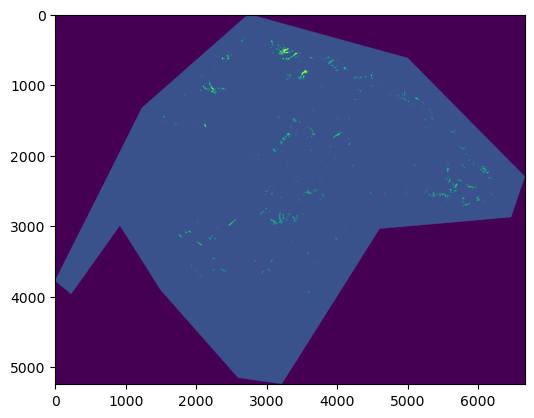

In [77]:
plt.imshow(changeCrosswalk[0,:,:])

In [81]:
# saving the tif file for change
rio.open(
        mainPath + 'data/classification/change.tif',
        'w',
        height=changeCrosswalk.shape[1],
        width=changeCrosswalk.shape[2],
        count=changeCrosswalk.shape[0],
        dtype=fullExt0920Read.dtype.name,
        crs=originalMap.crs,
        transform=originalMap.transform,
        compress='lzw'
    ).write(changeCrosswalk)

In [83]:
# converting the raster to vector
command = [
    'gdal_polygonize.py',
    mainPath + 'data/classification/change.tif',
    '-b',
    '1',
    '-f',
    'ESRI Shapefile',
    mainPath + 'data/classification_vector/V2/change.shp',
    'change',
    'Class'
]
Popen(command).wait()

0...10...20...30...40...50...60...70...80...90...Creating output /projectnb/modislc/users/sjstone/above/data/classification_vector/V2/change.shp of format ESRI Shapefile.
100 - done.


0